<font size=10>**TASK 2 - SENTIMENT ANALYSIS**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How strong is the relationship between the polarity of a comments and its score?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Sentiment Analysis](#3)
    - [3.1 Specific Data Preparation](#3_1)
    - [3.2 Model Implementation](#3_2)
    - [3.3 Model Evaluation](#3_3)
- [4. Professors Implementation of Sentiment Analysis](#4)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from scipy.stats import pearsonr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from nltk.tokenize import PunktSentenceTokenizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from sentiment_prep import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Sentiment Analysis**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="3_1"></a>
  
[Back to TOC](#toc)

In [7]:
dataset["preproc_content"] =\
      dataset["text"].map(lambda content : main_pipeline(content,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ))

In [8]:
sent_tokenizer = PunktSentenceTokenizer()

dataset["preproc_sentences"] =\
      dataset["text"].map(lambda content : [main_pipeline(sentence,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ) for sentence in sent_tokenizer.tokenize(content)])

In [9]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=42).values)
print("\nPreprocessed Content Sample:\n")
print(dataset[['preproc_content']].sample(1, random_state=42).values)
print("\nPreprocessed Sentences Sample:\n")
print(dataset[['preproc_sentences']].sample(1, random_state=42).values)

Original Text Sample:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Preprocessed Content Sample:

[['Wife & I visited The Red Eyed Mule . The food was good . The biscuits are soft, tasty and just right.The service was great . Atmosphere clean and positive . The decorations on wall is very educational . Overall, enjoyed my breakfast experience at Red Eyed Mule . We plan to return.']]

Preprocessed Sentences Sample:

[[list(['Wife & I visited The Red Eyed Mule.', 'The food was good.', 'The biscuits are soft, tasty and just right.The service was great.', 'Atmosphere clean and positive.', 'The decorations on wall is very educational.', 'Overall, enjoyed my breakfast experience at Red Eyed Mule.', 'We plan to return.'])]]


In sentiment analysis, we **skip feature extraction** and **vectorization** steps, from the *text mining fluxogram*, because the tools we use (VADER and TextBlob) work directly with raw text.

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="3_2"></a>
  
[Back to TOC](#toc)

### <font color='#BFD72F' size=6>3.2.1 VADER Sentiment Analysis</font> <a class="anchor" id="3_2_1"></a>
  
[Back to TOC](#toc)

#### **3.2.1.1 Compound Score of Entire Review** <a class="anchor" id="3_2_1_1"></a>
*Sentiment score computed from the full text of each review.*

In [10]:
dataset["content_polarity_vader"] = dataset["preproc_content"].map(lambda review: vader_wrapper(review))

In [11]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nVader Polarity Sample:\n")
print(dataset[['content_polarity_vader']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Vader Polarity Sample:

[[0.9485]]


#### **3.2.1.2 Average Compound Score Across Sentences** <a class="anchor" id="3_2_1_2"></a>
*Mean sentiment score calculated from individual sentence-level analysis.*

In [12]:
dataset["mean_sentence_polarity_vader"] = dataset["preproc_sentences"].map(lambda review: vader_wrapper(review))

In [13]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Vader Polarity Sample Across Sentences:\n")
print(dataset[['mean_sentence_polarity_vader']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Vader Polarity Sample Across Sentences:

[[0.33127143]]


#### **3.2.1.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_1_3"></a>
*Scores Statistical comparison of both compound scoring approaches.*

In [14]:
pearson_r_vader, p_value_vader = pearsonr(dataset["content_polarity_vader"],dataset["mean_sentence_polarity_vader"])
print(f'Pearson correlation of content wise vader with mean sentences vader is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence.')

Pearson correlation of content wise vader with mean sentences vader is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence.


### <font color='#BFD72F' size=6>3.2.2 TextBlob Sentiment Analysis</font> <a class="anchor" id="3_2_2"></a>
  
[Back to TOC](#toc)

#### **3.2.2.1 Polarity Score of Entire Review** <a class="anchor" id="3_2_2_1"></a>
*Sentiment polarity derived from the full review text.*

In [15]:
dataset["content_polarity_textblob"] = dataset["preproc_content"].map(lambda review: textblob_wrapper(review))

In [16]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nTextblob Polarity Sample:\n")
print(dataset[['content_polarity_textblob']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Textblob Polarity Sample:

[[0.30189394]]


#### **3.2.2.2 Average Polarity Across Sentences** <a class="anchor" id="3_2_2_2"></a>
*Mean polarity score based on sentence-level breakdown.*

In [17]:
dataset["mean_sentence_polarity_textblob"] = dataset["preproc_sentences"].map(lambda review: textblob_wrapper(review))

In [18]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Textblob Polarity Sample Across Sentences:\n")
print(dataset[['mean_sentence_polarity_textblob']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Textblob Polarity Sample Across Sentences:

[[0.27694805]]


#### **3.2.2.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_2_3"></a>
*Polarity Evaluating consistency between aggregate and granular polarity scores.*

In [19]:
pearson_r_textblob, p_value_textblob = pearsonr(dataset["content_polarity_textblob"],dataset["mean_sentence_polarity_textblob"])
print(f'Pearson correlation of content wise textblob with mean sentences textblob is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence')

Pearson correlation of content wise textblob with mean sentences textblob is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence


## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="3_3"></a>
  
[Back to TOC](#toc)

*VADER vs TextBlob: Performance Evaluation Using RMSE and MAPE*

In [20]:
scaler = MinMaxScaler()

# Normalize
normalized_score = scaler.fit_transform(dataset["stars"].to_numpy().reshape(-1, 1))

normalized_polarity_vader = scaler.fit_transform(dataset["content_polarity_vader"].to_numpy().reshape(-1, 1))
normalized_polarity_vader_mean_sentences = scaler.fit_transform(dataset["mean_sentence_polarity_vader"].to_numpy().reshape(-1, 1))

normalized_polarity_textblob = scaler.fit_transform(dataset["content_polarity_textblob"].to_numpy().reshape(-1, 1))
normalized_polarity_textblob_mean_sentences = scaler.fit_transform(dataset["mean_sentence_polarity_textblob"].to_numpy().reshape(-1, 1))

In [21]:
# Compute metrics
metrics = {
    "Vader VS Stars": {},
    "Vader (mean sentences) VS Stars": {},
    "TextBlob VS Stars": {},
    "TextBlob (mean sentences) VS Stars": {},
    "Vader vs TextBlob": {}
}

In [22]:
# Vader VS Stars
pearson_r_vader, _ = pearsonr(normalized_score.reshape(-1), normalized_polarity_vader.reshape(-1))
rmse_vader = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_vader.reshape(-1))
mape_vader = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_vader.reshape(-1)+1)

metrics["Vader VS Stars"]["Pearson R"] = round(pearson_r_vader, 3)
metrics["Vader VS Stars"]["RMSE"] = round(rmse_vader, 3)
metrics["Vader VS Stars"]["MAPE"] = round(mape_vader, 3)

In [23]:
# Vader (mean sentences) VS Stars
pearson_r_vader, _ = pearsonr(normalized_score.reshape(-1), normalized_polarity_vader_mean_sentences.reshape(-1))
rmse_vader = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_vader_mean_sentences.reshape(-1))
mape_vader = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_vader_mean_sentences.reshape(-1)+1)

metrics["Vader (mean sentences) VS Stars"]["Pearson R"] = round(pearson_r_vader, 3)
metrics["Vader (mean sentences) VS Stars"]["RMSE"] = round(rmse_vader, 3)
metrics["Vader (mean sentences) VS Stars"]["MAPE"] = round(mape_vader, 3)

In [24]:
# TextBlob VS Stars
pearson_r_textblob, _ = pearsonr(normalized_score.reshape(-1), normalized_polarity_textblob.reshape(-1))
rmse_textblob = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_textblob.reshape(-1))
mape_textblob = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_textblob.reshape(-1)+1)

metrics["TextBlob VS Stars"]["Pearson R"] = round(pearson_r_textblob, 3)
metrics["TextBlob VS Stars"]["RMSE"] = round(rmse_textblob, 3)
metrics["TextBlob VS Stars"]["MAPE"] = round(mape_textblob, 3)

In [25]:
# TextBlob (mean sentences) VS Stars
pearson_r_textblob, _ = pearsonr(normalized_score.reshape(-1), normalized_polarity_textblob_mean_sentences.reshape(-1))
rmse_textblob = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_textblob_mean_sentences.reshape(-1))
mape_textblob = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_textblob_mean_sentences.reshape(-1)+1)

metrics["TextBlob (mean sentences) VS Stars"]["Pearson R"] = round(pearson_r_textblob, 3)
metrics["TextBlob (mean sentences) VS Stars"]["RMSE"] = round(rmse_textblob, 3)
metrics["TextBlob (mean sentences) VS Stars"]["MAPE"] = round(mape_textblob, 3)

In [26]:
# Vader vs TextBlob
pearson_r_vt, _ = pearsonr(normalized_polarity_vader.reshape(-1), normalized_polarity_textblob.reshape(-1))
rmse_vt = mean_squared_error(normalized_polarity_vader.reshape(-1), normalized_polarity_textblob.reshape(-1))
mape_vt = mean_absolute_percentage_error(normalized_polarity_vader.reshape(-1)+1, normalized_polarity_textblob.reshape(-1)+1)

metrics["Vader vs TextBlob"]["Pearson R"] = round(pearson_r_vt, 3)
metrics["Vader vs TextBlob"]["RMSE"] = round(rmse_vt, 3)
metrics["Vader vs TextBlob"]["MAPE"] = round(mape_vt, 3)

In [27]:
# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df

,Vader VS Stars,Vader (mean sentences) VS Stars,TextBlob VS Stars,TextBlob (mean sentences) VS Stars,Vader vs TextBlob
Pearson R,0.677,0.671,0.634,0.614,0.634
RMSE,0.071,0.086,0.087,0.094,0.046
MAPE,0.128,0.163,0.160,0.168,0.104


In [35]:
dataset["normalized_score"] = normalized_score.reshape(-1)
dataset["normalized_polarity_vader"] = normalized_polarity_vader.reshape(-1)
dataset["normalized_polarity_textblob"] = normalized_polarity_textblob.reshape(-1)
dataset["normalized_polarity_vader_mean_sentences"] = normalized_polarity_vader_mean_sentences.reshape(-1)
dataset["normalized_polarity_textblob_mean_sentences"] = normalized_polarity_textblob_mean_sentences.reshape(-1)

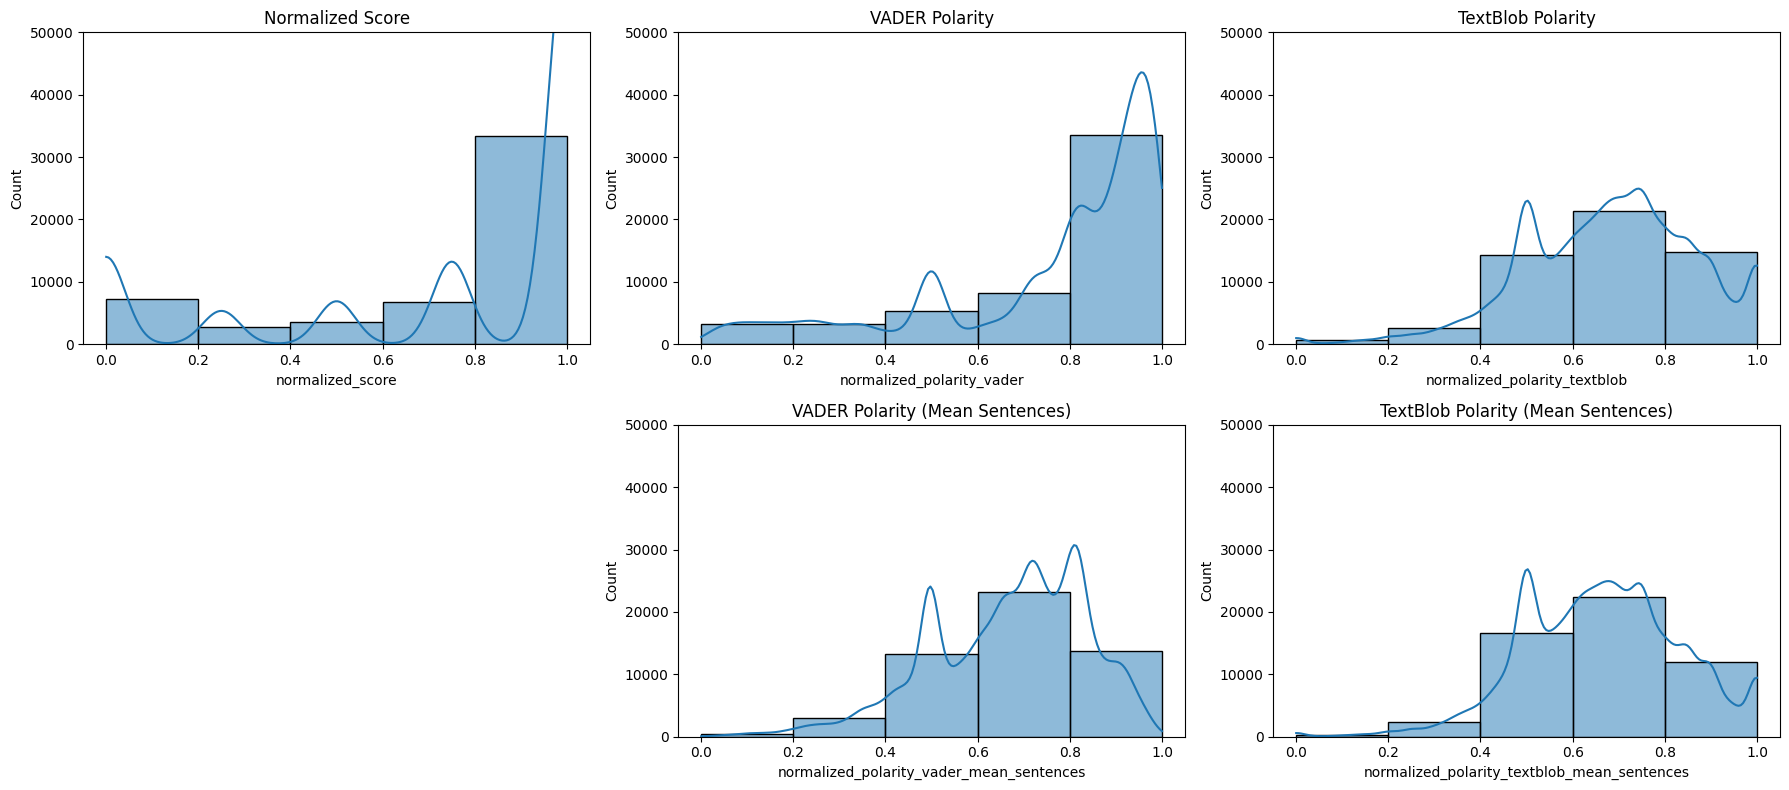

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # 2 rows, 3 columns

sns.histplot(dataset["normalized_score"], kde=True, bins=5, ax=axes[0, 0])
axes[0, 0].set_ylim(0, 50000)
axes[0, 0].set_title("Normalized Score")

sns.histplot(dataset["normalized_polarity_vader"], kde=True, bins=5, ax=axes[0, 1])
axes[0, 1].set_ylim(0, 50000)
axes[0, 1].set_title("VADER Polarity")

sns.histplot(dataset["normalized_polarity_textblob"], kde=True, bins=5, ax=axes[0, 2])
axes[0, 2].set_ylim(0, 50000)
axes[0, 2].set_title("TextBlob Polarity")

axes[1, 0].axis('off')

sns.histplot(dataset["normalized_polarity_vader_mean_sentences"], kde=True, bins=5, ax=axes[1, 1])
axes[1, 1].set_ylim(0, 50000)
axes[1, 1].set_title("VADER Polarity (Mean Sentences)")

sns.histplot(dataset["normalized_polarity_textblob_mean_sentences"], kde=True, bins=5, ax=axes[1, 2])
axes[1, 2].set_ylim(0, 50000)
axes[1, 2].set_title("TextBlob Polarity (Mean Sentences)")

plt.tight_layout()
plt.show()

## <font color='#BFD72F' size=6>3.4 Answer the Question</font> <a class="anchor" id="3_4"></a>
  
[Back to TOC](#toc)

**How strong is the relationship between the polarity of a comments and its score?**

*(Sentiment Analysis with Correlation Matrix)*

Based on our analysis, **Vader** shows a slightly stronger correlation with review scores compared to TextBlob. 

Therefore, we focus on the correlation between the Vader polarity when applied to the **entire review** (rather than individual sentences) and its corresponding star rating, which makes sense as the majority of reviews have 1 or 2 sentences  

- **Pearson correlation (R):** 0.677  
- **RMSE:** 0.071  
- **MAPE:** 0.128  

While the correlation is moderate—not exceptionally strong—it still reflects a **clear trend**:  
> More positive comments tend to receive higher star ratings.

The distribution plots support this observation. VADER polarity scores, when applied to full reviews, show a consistent alignment with normalized star ratings. This suggests that>
> VADER effectively captures the overall sentiment direction, even if it doesn't account for all the variability in user ratings.

In summary, VADER offers a reliable signal for sentiment analysis in short-form reviews, making it a suitable choice for predicting user satisfaction.